In [138]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import os

In [214]:
def generate_minimap():
    def place_vision(img, cx, cy, r):
        h, w, _ = img.shape
        mask = np.zeros((h, w), np.float32)
        cv2.circle(mask, (cx, cy), r, 1.0, -1)
        mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=3)
        
        img_float = img.astype(np.float32)
        img_float *= (1 + 2 * mask[..., None])
        
        img_result = np.clip(img_float, 0, 255).astype(np.uint8)
        return img_result
    
    def place_image(base, img, x, y):
        base_h, base_w = base.shape[:2]
        img_h, img_w = img.shape[:2]
        x1 = max(x, 0)
        y1 = max(y, 0)
        x2 = min(x + img_w, base_w)
        y2 = min(y + img_h, base_h)
    
        # No overlap
        if x1 >= x2 or y1 >= y2:
            return base
    
        # Corresponding region in overlay
        img_x1 = x1 - x
        img_y1 = y1 - y
        img_x2 = img_x1 + (x2 - x1)
        img_y2 = img_y1 + (y2 - y1)
    
        # Convert to float
        base = base.astype(np.float32)
        img = img.astype(np.float32)
    
        # Extract alpha and expand dims
        alpha = img[img_y1:img_y2, img_x1:img_x2, 3] / 255.0
        alpha = alpha[..., None]
    
        # Blend
        base[y1:y2, x1:x2, :] = (
            base[y1:y2, x1:x2, :] * (1 - alpha) +
            img[img_y1:img_y2, img_x1:img_x2, :3] * alpha
        )
    
        return base.astype(np.uint8)
        
    def generate_background():
        base_image_name = random.choice(os.listdir('league_icons/minimap/base'))
        base = cv2.imread(os.path.join('league_icons/minimap/base', base_image_name), cv2.IMREAD_UNCHANGED)
        base[:, :, 3] //= 3
        blackboard = np.zeros(shape=[base.shape[0], base.shape[1], 3])
        base = place_image(blackboard, base, 0, 0)
        do_atackan_overlay = random.randint(0, 1) == 1
        if do_atackan_overlay:
            overlay_image_name = random.choice(os.listdir('league_icons/minimap/overlay'))
            overlay_image = cv2.imread(os.path.join('league_icons/minimap/overlay', overlay_image_name), cv2.IMREAD_UNCHANGED)
            base = place_image(base, overlay_image, 0, 0)
        return base

    def draw_shops(base):
        shop_icon = cv2.imread('league_icons/misc/shop.png', cv2.IMREAD_UNCHANGED)
        shop_icon = cv2.resize(shop_icon,  None, fx=0.7, fy=0.7)
        base = place_image(base, shop_icon, -10, 225)
        base = place_image(base, shop_icon, 225, -7)
        return base
        
    base = generate_background()
    base = draw_shops(base)
    base = place_vision(base, 40, 40, 40)
    # draw minions
    # draw flowers
    # draw towers
    # draw wards
    # draw champions
    # draw champion overlays (recalls, teleports, shen ult)
    # draw pings
    # draw camera
    return cv2.cvtColor(base, cv2.COLOR_BGR2RGB)

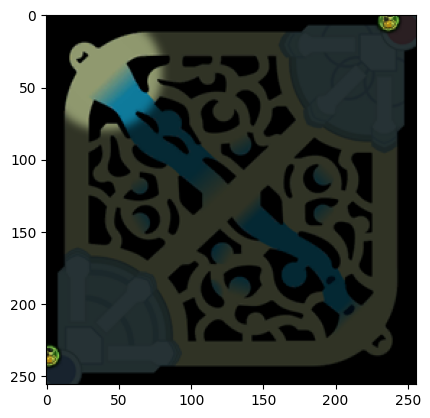

In [215]:
img = generate_minimap()
plt.imshow(img)